# Line detection with clustering
Clustering is an unsupervised machine learning technique that groups similar, unlabeled data points into clusters based on shared characteristics. Its goal is to organize data into meaningful groups, revealing natural structures and patterns within the data. This process is used in various fields like market segmentation, image analysis, and social network analysis to understand large datasets, simplify information, and discover underlying trends.

Import libraries

In [1098]:
import matplotlib.pyplot as plt
from sklearn import cluster
import numpy as np
import cv2 as cv
import random
import os

Load images

In [1099]:
filenames = os.listdir("./images/batch01")
imgs = []

for filename in filenames:
    imgs.append(cv.imread(f"./images/batch01/{filename}", cv.IMREAD_GRAYSCALE))

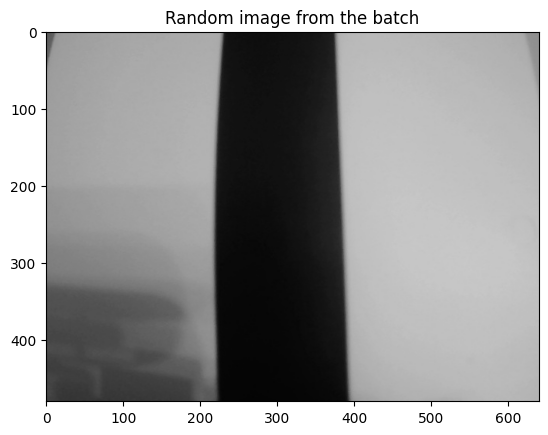

In [1100]:
random_img = random.choice(imgs)
plt.title("Random image from the batch")
plt.imshow(cv.cvtColor(random_img, cv.COLOR_BGR2RGB))
plt.show()

In [1101]:
random_img.shape

(480, 640)

Constrast enhancement

In [1102]:
bgr_img = cv.cvtColor(random_img, cv.COLOR_GRAY2BGR)
ycrcb_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2YCrCb)
y_channel, cr_channel, cb_channel = cv.split(ycrcb_img)

y_channel_streched = cv.normalize(y_channel, None, 0, 255, cv.NORM_MINMAX)
contrast_ycrcb_img = cv.merge([y_channel_streched, cr_channel, cb_channel])

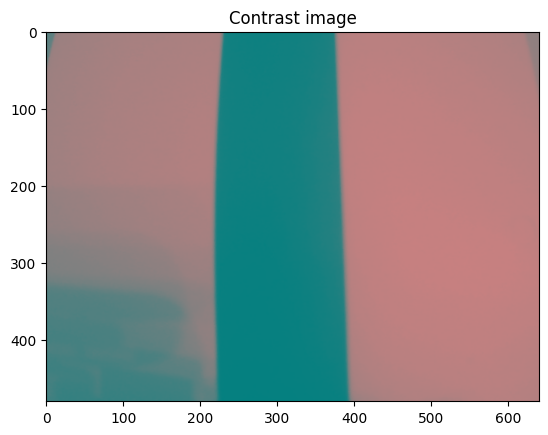

In [1103]:

plt.title("Contrast image")
plt.imshow(ycrcb_img)
plt.show()

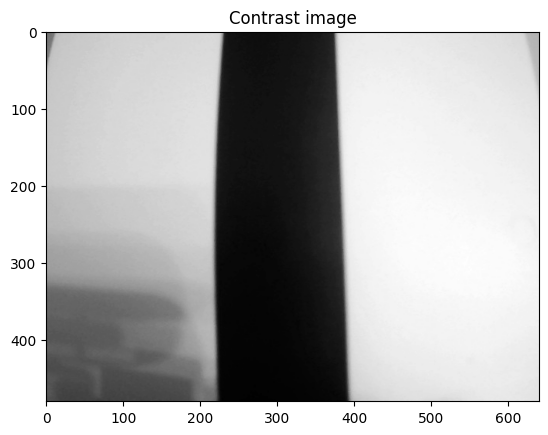

In [1104]:
contrast_img = cv.cvtColor(contrast_ycrcb_img, cv.COLOR_YCR_CB2BGR)
contrast_img = cv.cvtColor(contrast_img, cv.COLOR_BGR2GRAY)
plt.title("Contrast image")
plt.imshow(cv.cvtColor(contrast_img, cv.COLOR_BGR2RGB))
plt.show()

Apply blur

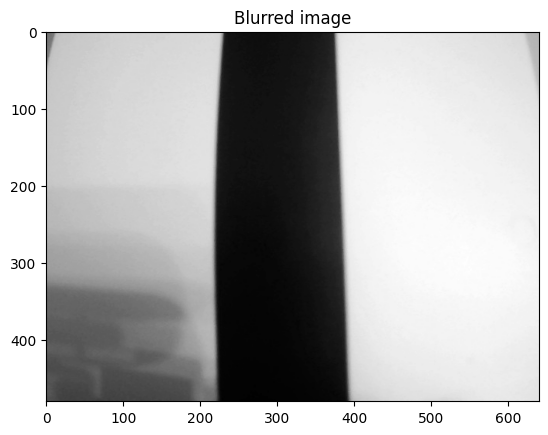

In [1105]:
FIRST_K_SIZE = (16, 16)
blurred_img = cv.blur(contrast_img, FIRST_K_SIZE)

plt.title("Blurred image")
plt.imshow(cv.cvtColor(contrast_img, cv.COLOR_BGR2RGB))
plt.show()

Apply K-means clustering

In [1106]:
n_clusters = 2
kmeans = cluster.KMeans(n_clusters=n_clusters)

In [1107]:
X = blurred_img.reshape(-1, 1).astype(float)
kmeans.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


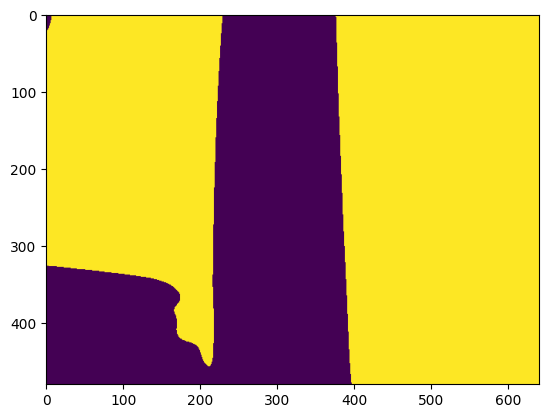

In [1108]:
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(random_img.shape) / 255

plt.imshow(segmented_img)